# 03 · Entropy, refrigeration and heat pumps

The second law sets limits: no heat engine beats Carnot, no refrigerator moves heat uphill for free, and
every real process creates entropy - and destroys the ability to do work. This notebook quantifies those
limits and applies them to the machine that heats and cools most buildings today: the vapour-compression
cycle, run as a refrigerator or as a heat pump.

**What you will learn**
- compute entropy generation and exergy destruction of processes
- use the Carnot limits for refrigerators and heat pumps
- analyse the vapour-compression cycle with property tables
- compare refrigerants and understand heat-pump performance

**Before you start:** notebooks 01-02  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import cycles, steam, tables
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Entropy generation in everyday processes
Throttling and heat exchange across a temperature difference are the workhorses of process plants - and
both generate entropy:

In [2]:
inlet = steam.properties(T=573.15, p=5e6)
outlet = steam.state_ph(1e5, inlet["h"])
print(f"throttling steam 5 MPa -> 1 bar: entropy generated {(outlet['s'] - inlet['s']):.1f} J/(kg K)")
T0 = 298.15
print(f"   exergy destroyed T0 * s_gen = {T0 * (outlet['s'] - inlet['s'])/1e3:.1f} kJ/kg of steam (out of a work potential of "
      f"{(inlet['h'] - steam.properties(T0, 1e5)['h'] - T0 * (inlet['s'] - steam.properties(T0, 1e5)['s']))/1e3:.0f} kJ/kg)")
Q, T_hot, T_cold = 1e6, 800.0, 400.0
print(f"1 MW of heat flowing from {T_hot:.0f} K to {T_cold:.0f} K: entropy generated {Q/T_cold - Q/T_hot:.0f} W/K, "
      f"i.e. {T0 * (Q/T_cold - Q/T_hot)/1e3:.0f} kW of work potential lost")

throttling steam 5 MPa -> 1 bar: entropy generated 1727.9 J/(kg K)
   exergy destroyed T0 * s_gen = 515.2 kJ/kg of steam (out of a work potential of 1078 kJ/kg)
1 MW of heat flowing from 800 K to 400 K: entropy generated 1250 W/K, i.e. 373 kW of work potential lost


The exergy (work potential) destroyed is $T_0 s_{gen}$: the pressure let down in a valve could have driven a turbine;
heat transferred across a large temperature difference could have driven a heat engine. Exergy accounting
finds where a process wastes its potential.

## The limits: Carnot

In [3]:
for T_cold_C in (-20, 0, 5):
    for T_hot_C in (30, 45):
        print(f"cold {T_cold_C:4d} degC, hot {T_hot_C:3d} degC: max COP refrigeration {cycles.carnot_cop(T_cold_C + 273.15, T_hot_C + 273.15):.2f}, "
              f"heat pump {cycles.carnot_cop(T_cold_C + 273.15, T_hot_C + 273.15, heat_pump=True):.2f}")

cold  -20 degC, hot  30 degC: max COP refrigeration 5.06, heat pump 6.06
cold  -20 degC, hot  45 degC: max COP refrigeration 3.89, heat pump 4.89
cold    0 degC, hot  30 degC: max COP refrigeration 9.10, heat pump 10.10
cold    0 degC, hot  45 degC: max COP refrigeration 6.07, heat pump 7.07
cold    5 degC, hot  30 degC: max COP refrigeration 11.13, heat pump 12.13
cold    5 degC, hot  45 degC: max COP refrigeration 6.95, heat pump 7.95


The closer the two temperatures, the more heat can be moved per unit of work. A heat pump warming a house from
5 degC to 45 degC could deliver almost 8 kW of heat per kW of electricity - in the ideal limit.

## The vapour-compression cycle
Evaporator (4 -> 1, heat absorbed at low temperature), compressor (1 -> 2), condenser (2 -> 3, heat rejected),
expansion valve (3 -> 4). A domestic freezer: R134a evaporating at -20 degC, condensing at 40 degC.

In [4]:
vc = cycles.vapor_compression("R134a", T_evaporator=253.15, T_condenser=313.15)
for k, st in vc["states"].items():
    print(f"state {k}: {st['phase']:<20} T = {st['T'] - 273.15:6.1f} degC, p = {st['p']/1e5:5.2f} bar, h = {st['h']/1e3:6.1f} kJ/kg" + (f", x = {st['x']:.3f}" if "x" in st else ""))
print(f"compressor work {vc['w_compressor']/1e3:.1f} kJ/kg, cooling effect {vc['q_evaporator']/1e3:.1f} kJ/kg")
print(f"COP cooling {vc['COP_cooling']:.2f}, heating {vc['COP_heating']:.2f}   (Carnot: {cycles.carnot_cop(253.15, 313.15):.2f})")

state 1: saturated vapour     T =  -20.0 degC, p =  1.33 bar, h =  386.6 kJ/kg
state 2: superheated vapour   T =   48.6 degC, p = 10.17 bar, h =  429.0 kJ/kg
state 3: saturated liquid     T =   40.0 degC, p = 10.17 bar, h =  256.4 kJ/kg
state 4: two-phase            T =  -20.0 degC, p =  1.33 bar, h =  256.4 kJ/kg, x = 0.389
compressor work 42.5 kJ/kg, cooling effect 130.1 kJ/kg
COP cooling 3.06, heating 4.06   (Carnot: 4.22)


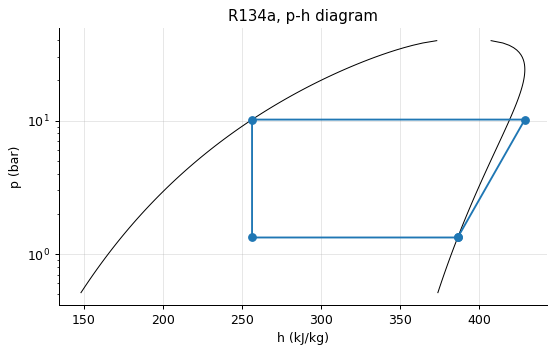

In [5]:
r134 = tables.FluidTable("R134a")
Ts = r134.T_sat
plt.semilogy([r134.saturated(T=T)["liquid"]["h"] / 1e3 for T in Ts], r134.p_sat / 1e5, "k", lw=0.8)
plt.semilogy([r134.saturated(T=T)["vapour"]["h"] / 1e3 for T in Ts], r134.p_sat / 1e5, "k", lw=0.8)
keys = ["1", "2", "3", "4", "1"]
plt.semilogy([vc["states"][k]["h"] / 1e3 for k in keys], [vc["states"][k]["p"] / 1e5 for k in keys], "o-")
plt.xlabel("h (kJ/kg)"); plt.ylabel("p (bar)"); plt.title("R134a, p-h diagram"); plt.show()

On the p-h diagram the cycle is a rectangle-like loop: the horizontal legs are the heat exchanged in the
evaporator and condenser, the compressor is the sloping leg, the valve a vertical drop. Even this ideal
cycle reaches only about three quarters of the Carnot COP: the throttling valve and the superheated
compressor discharge are irreversibilities built into the cycle itself.

## What changes the COP?

In [6]:
rows = []
for T_ev in (-30, -20, -10, 0):
    for T_cd in (30, 40, 50):
        v = cycles.vapor_compression("R134a", T_ev + 273.15, T_cd + 273.15)
        rows.append((T_ev, T_cd, v["COP_cooling"], v["p_high"] / v["p_low"], v["states"]["2"]["T"] - 273.15))
print(pd.DataFrame(rows, columns=["T_evap (degC)", "T_cond (degC)", "COP", "pressure ratio", "discharge T (degC)"]).round(2).to_string(index=False))

 T_evap (degC)  T_cond (degC)  COP  pressure ratio  discharge T (degC)
           -30             30 3.02            9.13               40.99
           -30             40 2.38           12.05               51.67
           -30             50 1.88           15.62               62.28
           -20             30 3.97            5.80               37.90
           -20             40 3.06            7.66               48.65
           -20             50 2.39            9.93               59.35
           -10             30 5.40            3.84               35.52
           -10             40 4.03            5.07               46.32
           -10             50 3.08            6.57               57.09
             0             30 7.82            2.63               33.67
             0             40 5.49            3.47               44.51
             0             50 4.06            4.50               55.35


Every degree the evaporator can be warmer, or the condenser colder, pays off - which is why heat exchangers
are oversized and condensers are placed where cooling is coldest. Real compressors are not isentropic:

In [7]:
for eta in (1.0, 0.8, 0.65):
    v = cycles.vapor_compression("R134a", 253.15, 313.15, eta_compressor=eta, superheat=5.0, subcooling=5.0)
    print(f"compressor efficiency {eta:.0%} (5 K superheat and subcooling): COP {v['COP_cooling']:.2f}, discharge {v['states']['2']['T'] - 273.15:.0f} degC")

compressor efficiency 100% (5 K superheat and subcooling): COP 3.25, discharge 53 degC
compressor efficiency 80% (5 K superheat and subcooling): COP 2.60, discharge 64 degC
compressor efficiency 65% (5 K superheat and subcooling): COP 2.11, discharge 76 degC


## Choosing a refrigerant
The same cycle with three refrigerants: R134a (a synthetic HFC being phased down for its global-warming
potential), ammonia (industrial refrigeration) and propane (R290, increasingly used in heat pumps):

In [8]:
rows = []
for fluid in ("R134a", "ammonia", "propane"):
    v = cycles.vapor_compression(fluid, 263.15, 313.15)
    rows.append((fluid, v["COP_cooling"], v["p_low"] / 1e5, v["p_high"] / 1e5, v["states"]["2"]["T"] - 273.15, v["q_evaporator"] / 1e3))
print(pd.DataFrame(rows, columns=["refrigerant", "COP", "p_evap (bar)", "p_cond (bar)", "discharge T (degC)", "cooling effect (kJ/kg)"]).round(2).to_string(index=False))

refrigerant  COP  p_evap (bar)  p_cond (bar)  discharge T (degC)  cooling effect (kJ/kg)
      R134a 4.03          2.01         10.17               46.32                  136.26
    ammonia 4.28          2.91         15.55              112.41                 1059.83
    propane 3.96          3.45         13.69               46.35                  256.51


The thermodynamic COPs are similar - the cycle, not the fluid, sets most of the efficiency. The fluids differ
in practical ways: ammonia's large cooling effect per kilogram means small compressors, but its discharge
temperature is high and it is toxic; propane is flammable but efficient and benign to the atmosphere;
R134a is safe to handle but a potent greenhouse gas. Refrigerant selection is engineering trade-off, with
thermodynamics only one voice.

## Heat pumps for buildings
A heat pump moves heat from the outdoor air into the house. As the outdoor temperature falls, the
evaporator must run colder and the COP drops - just when the house needs most heat:

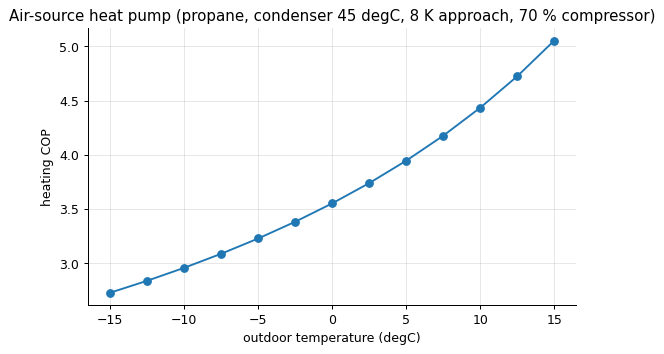

COP at +10 degC: 4.43; at -15 degC: 2.73


In [9]:
T_out = np.arange(-15, 16, 2.5)
cop = [cycles.vapor_compression("propane", T + 273.15 - 8, 273.15 + 45, eta_compressor=0.7)["COP_heating"] for T in T_out]
plt.plot(T_out, cop, "o-"); plt.xlabel("outdoor temperature (degC)"); plt.ylabel("heating COP")
plt.title("Air-source heat pump (propane, condenser 45 degC, 8 K approach, 70 % compressor)"); plt.show()
print(f"COP at +10 degC: {cop[-3]:.2f}; at -15 degC: {cop[0]:.2f}")

Even at -15 degC the heat pump delivers more than twice the heat of an electric resistance heater. Lowering
the condenser temperature - underfloor heating at 35 degC instead of radiators at 55 degC - raises the COP
further; that is why heat-pump buildings are designed around low-temperature heat emitters.

## Inside the algorithm: the COP from table look-ups
The four enthalpies come straight from the tables: h1 saturated vapour at T_evap, h2 from (p_cond, s1), h3 saturated
liquid at T_cond, h4 = h3 (throttling):

In [10]:
h1 = r134.saturated(T=253.15)["vapour"]["h"]; s1 = r134.saturated(T=253.15)["vapour"]["s"]
p_c = r134.psat(313.15)
h2 = r134.superheated(p_c, s=s1)["h"]
h3 = r134.saturated(T=313.15)["liquid"]["h"]
print(f"by hand: COP = (h1 - h4)/(h2 - h1) = {(h1 - h3)/(h2 - h1):.3f};  library: {vc['COP_cooling']:.3f}")

by hand: COP = (h1 - h4)/(h2 - h1) = 3.063;  library: 3.063


## Exercises
1. A cold store must hold -25 degC with ammonia condensing at 35 degC. Compute the COP, the compressor discharge temperature and the pressure ratio, and compare with a two-stage arrangement (ideal intercooling at the geometric-mean pressure - treat it as two cycles in series with an intermediate temperature of 0 degC).
2. For the propane heat pump, compare the seasonal energy use of radiators (condenser 55 degC) with underfloor heating (condenser 35 degC) for a house needing 12 000 kWh of heat per winter at an average outdoor temperature of 4 degC.
3. **Implement it yourself:** compute the entropy generated in the real compressor of the R134a cycle (80 % efficiency) from the table states, and the exergy destroyed per kilogram of refrigerant.